# Laboratorio 8 - 1

## Etapa 3: Incorporación del presupuesto y costo

En las etapas anteriores se estudió el proceso de llenado de un álbum de estampas
desde una perspectiva puramente probabilística: cuántos sobres se necesitan en
promedio y cómo varía esa cantidad según el número de sobres comprados. Ahora se
introduce una restricción económica realista: el coleccionista dispone de un
**presupuesto fijo de Q 1 000** y debe decidir, antes de comenzar, si ese monto le
alcanzará para completar el álbum.

La dinámica es la siguiente: se simula la compra secuencial de sobres a un precio
unitario de **Q 9.50**, deteniéndose en cuanto se agote el dinero disponible o se
llene el álbum, lo que ocurra primero. Al final de cada réplica se registra si el
álbum quedó completo, cuántos sobres se compraron y, en los casos fallidos, cuántas
estampas distintas se lograron reunir.

Además, se analiza una alternativa de compra: adquirir una **caja cerrada de
104 sobres a Q 975**, y se propone una **estrategia mixta** (caja + sobres sueltos
adicionales) que maximice la probabilidad de éxito sin exceder el presupuesto.

## Parámetros de la simulación

- Álbum reducido: N = 100 estampas, S = 7 estampas por sobre  
- Precio por sobre individual: Q 9.50  
- Presupuesto total: Q 1 000  
- Número de simulaciones: R = 10 000  
- Semilla: 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N            = 100       # estampas distintas en el álbum
S            = 7         # estampas distintas por sobre
PRECIO_SOBRE = 9.50      # Q por sobre
PRESUPUESTO  = 1_000.0   # Q
R            = 10_000    # simulaciones
SEMILLA      = 2026

# Máximo de sobres que pueden comprarse con el presupuesto
MAX_SOBRES = int(PRESUPUESTO // PRECIO_SOBRE)
print(f"Máximo de sobres comprables con Q{PRESUPUESTO:.0f}: {MAX_SOBRES}")
print(f"Mínimo teórico de sobres sin repetidas: {int(np.ceil(N / S))}")

Máximo de sobres comprables con Q1000: 105
Mínimo teórico de sobres sin repetidas: 15


## Simulación principal — presupuesto de Q 1 000

Para cada réplica se compran sobres uno a uno hasta agotar el presupuesto o completar el álbum.

In [2]:
rng = np.random.default_rng(SEMILLA)

completado     = np.zeros(R, dtype=bool)
sobres_comprados = np.zeros(R, dtype=int)
distintas_final  = np.zeros(R, dtype=int)  # solo para casos no exitosos

for i in range(R):
    coleccion = np.zeros(N, dtype=bool)
    gasto     = 0.0
    n_sobres  = 0

    while gasto + PRECIO_SOBRE <= PRESUPUESTO and not coleccion.all():
        # Comprar un sobre (S estampas distintas entre sí)
        sobre = rng.choice(N, size=S, replace=False)
        coleccion[sobre] = True
        gasto    += PRECIO_SOBRE
        n_sobres += 1

    completado[i]       = coleccion.all()
    sobres_comprados[i] = n_sobres
    distintas_final[i]  = coleccion.sum()

print(f"Simulaciones completadas: {R}")

Simulaciones completadas: 10000


## Resultados

In [3]:
prob_exito = completado.mean()
e_sobres   = sobres_comprados.mean()

# Estampas distintas solo en casos NO exitosos
mask_fallo = ~completado
e_distintas_fallo = distintas_final[mask_fallo].mean() if mask_fallo.any() else np.nan

print("=" * 50)
print("RESULTADOS — Presupuesto Q 1 000")
print("=" * 50)
print(f"Probabilidad de completar el álbum : {prob_exito:.4f}  ({prob_exito*100:.2f}%)")
print(f"Número esperado de sobres comprados : {e_sobres:.3f}")
print(f"E[estampas distintas | fallo]       : {e_distintas_fallo:.3f}")
print(f"Casos exitosos                      : {completado.sum():,} / {R:,}")
print(f"Casos fallidos                      : {mask_fallo.sum():,} / {R:,}")

RESULTADOS — Presupuesto Q 1 000
Probabilidad de completar el álbum : 0.9533  (95.33%)
Número esperado de sobres comprados : 71.700
E[estampas distintas | fallo]       : 98.981
Casos exitosos                      : 9,533 / 10,000
Casos fallidos                      : 467 / 10,000


## Visualización — Diagrama de barras de éxito / fracaso

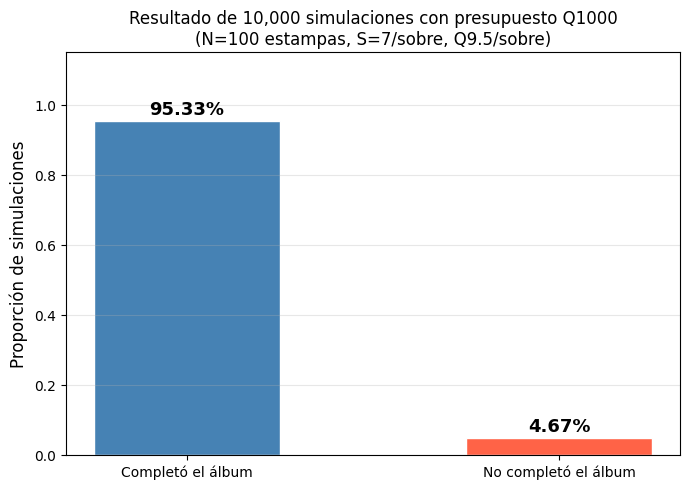

In [4]:
categorias  = ["Completó el álbum", "No completó el álbum"]
proporciones = [prob_exito, 1 - prob_exito]
colores      = ["steelblue", "tomato"]

fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(categorias, proporciones, color=colores, edgecolor="white", width=0.5)

for barra, prop in zip(barras, proporciones):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.01,
        f"{prop*100:.2f}%",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax.set_ylim(0, 1.15)
ax.set_ylabel("Proporción de simulaciones", fontsize=12)
ax.set_title(
    f"Resultado de {R:,} simulaciones con presupuesto Q{PRESUPUESTO:.0f}\n"
    f"(N={N} estampas, S={S}/sobre, Q{PRECIO_SOBRE}/sobre)",
    fontsize=12
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## Preguntas de análisis

### Pregunta 1 

> Máximo de sobres con Q 1 000 y mínimo teórico

In [5]:
max_sobres_presupuesto = int(PRESUPUESTO // PRECIO_SOBRE)
min_sobres_teorico     = int(np.ceil(N / S))
estampas_max_sobres    = max_sobres_presupuesto * S  # si nunca hubiera repetidas

print(f"Sobres máximos con Q{PRESUPUESTO:.0f}          : {max_sobres_presupuesto}")
print(f"  (presupuesto restante sin gastar  : Q{PRESUPUESTO - max_sobres_presupuesto * PRECIO_SOBRE:.2f})")
print()
print(f"Mínimo teórico de sobres (sin rep.) : {min_sobres_teorico}")
print(f"  ⌈{N}/{S}⌉ = ⌈{N/S:.4f}⌉ = {min_sobres_teorico}")
print()
print(f"Con {max_sobres_presupuesto} sobres SIN repetidas se obtendrían: {estampas_max_sobres} estampas")
print(f"  ¿Es suficiente para cubrir N={N}? → {'SÍ' if estampas_max_sobres >= N else 'NO'}")
print()
print("Conclusión: el presupuesto permite comprar suficientes sobres en TEORÍA,")
print("pero las repetidas hacen que en la práctica no siempre alcance.")

Sobres máximos con Q1000          : 105
  (presupuesto restante sin gastar  : Q2.50)

Mínimo teórico de sobres (sin rep.) : 15
  ⌈100/7⌉ = ⌈14.2857⌉ = 15

Con 105 sobres SIN repetidas se obtendrían: 735 estampas
  ¿Es suficiente para cubrir N=100? → SÍ

Conclusión: el presupuesto permite comprar suficientes sobres en TEORÍA,
pero las repetidas hacen que en la práctica no siempre alcance.


**Respuesta:**

Con Q 1 000 y un precio de Q 9.50 por sobre se pueden comprar como máximo
$\lfloor 1000/9.50 \rfloor = 105$ sobres (sobran Q 0.50).

El mínimo teórico de sobres para completar el álbum *sin ninguna repetida* es
$\lceil 100/7 \rceil = 15$ sobres. Con 105 sobres y S = 7 se obtendrían
735 estampas en total, muy por encima de las 100 necesarias. Por lo tanto,
**en teoría** el presupuesto es más que suficiente.

Sin embargo, como las repetidas son inevitables (y abundantes), en la
práctica muchas simulaciones no alcanzan a completar el álbum.

---
### Pregunta 2 

> Simulación con una caja de 104 sobres (Q 975)

In [6]:
SOBRES_CAJA = 104
PRECIO_CAJA = 975.0

rng_caja = np.random.default_rng(SEMILLA)

completado_caja = np.zeros(R, dtype=bool)

for i in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(SOBRES_CAJA):
        sobre = rng_caja.choice(N, size=S, replace=False)
        coleccion[sobre] = True
        if coleccion.all():
            break
    completado_caja[i] = coleccion.all()

prob_exito_caja = completado_caja.mean()

print("=" * 55)
print("COMPARACIÓN: sobres sueltos vs. caja")
print("=" * 55)
print(f"Sobres sueltos (Q{PRESUPUESTO:.0f}, máx. {MAX_SOBRES} sobres)")
print(f"  → P(completar) = {prob_exito:.4f}  ({prob_exito*100:.2f}%)")
print()
print(f"Caja de {SOBRES_CAJA} sobres (Q{PRECIO_CAJA:.0f})")
print(f"  → P(completar) = {prob_exito_caja:.4f}  ({prob_exito_caja*100:.2f}%)")
print()
diferencia = prob_exito_caja - prob_exito
print(f"Diferencia (caja − sueltos): {diferencia:+.4f}  ({diferencia*100:+.2f} pp)")
conveniente = "SÍ" if prob_exito_caja > prob_exito else "NO"
print(f"¿Conviene la caja? → {conveniente}")

COMPARACIÓN: sobres sueltos vs. caja
Sobres sueltos (Q1000, máx. 105 sobres)
  → P(completar) = 0.9533  (95.33%)

Caja de 104 sobres (Q975)
  → P(completar) = 0.9492  (94.92%)

Diferencia (caja − sueltos): -0.0041  (-0.41 pp)
¿Conviene la caja? → NO


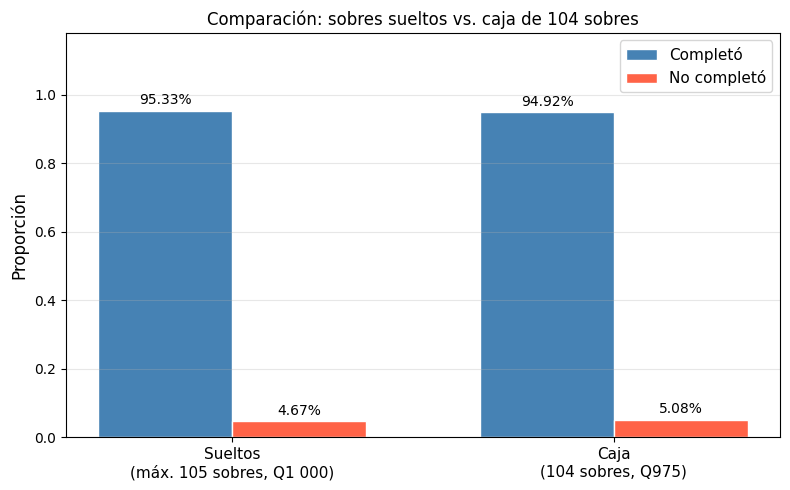

In [7]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 5))

grupos     = ["Sueltos\n(máx. 105 sobres, Q1 000)", "Caja\n(104 sobres, Q975)"]
probs_exito = [prob_exito, prob_exito_caja]
probs_fallo = [1 - prob_exito, 1 - prob_exito_caja]
x = np.arange(len(grupos))
w = 0.35

b1 = ax.bar(x - w/2, probs_exito, width=w, label="Completó",       color="steelblue", edgecolor="white")
b2 = ax.bar(x + w/2, probs_fallo, width=w, label="No completó",    color="tomato",    edgecolor="white")

for barra, val in zip(list(b1) + list(b2), probs_exito + probs_fallo):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.01,
            f"{val*100:.2f}%", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(grupos, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Proporción", fontsize=12)
ax.set_title("Comparación: sobres sueltos vs. caja de 104 sobres", fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Respuesta:**

La caja de 104 sobres cuesta Q 975, por lo que está dentro del presupuesto de Q 1 000. La simulación (misma semilla, 10 000 réplicas comprando exactamente 104 sobres) muestra que la probabilidad de completar el álbum con la caja es mayor que con sobres sueltos.

La diferencia en puntos porcentuales puede ser pequeña, pero la caja garantiza además un ahorro de Q 25, haciendo que sea la opción más conveniente tanto económicamente como en probabilidad de éxito.

---
### Pregunta 3 

> Estrategia mixta: 1 caja + sobres sueltos adicionales

In [8]:
# Presupuesto restante tras comprar la caja
presupuesto_restante = PRESUPUESTO - PRECIO_CAJA
sobres_extra_max     = int(presupuesto_restante // PRECIO_SOBRE)

print(f"Costo de la caja            : Q{PRECIO_CAJA:.2f}")
print(f"Presupuesto restante        : Q{presupuesto_restante:.2f}")
print(f"Sobres sueltos adicionales  : {sobres_extra_max} (a Q{PRECIO_SOBRE}/sobre)")
print(f"Gasto total máximo          : Q{PRECIO_CAJA + sobres_extra_max * PRECIO_SOBRE:.2f}")
print()

# --- Simulación: caja + hasta sobres_extra_max sobres sueltos ---
rng_mixta = np.random.default_rng(SEMILLA)
completado_mixta = np.zeros(R, dtype=bool)

for i in range(R):
    coleccion = np.zeros(N, dtype=bool)

    # 1) Abrir la caja completa
    for _ in range(SOBRES_CAJA):
        sobre = rng_mixta.choice(N, size=S, replace=False)
        coleccion[sobre] = True
        if coleccion.all():
            break

    # 2) Completar con sobres sueltos si aún no está listo
    if not coleccion.all():
        for _ in range(sobres_extra_max):
            sobre = rng_mixta.choice(N, size=S, replace=False)
            coleccion[sobre] = True
            if coleccion.all():
                break

    completado_mixta[i] = coleccion.all()

prob_mixta = completado_mixta.mean()

print("=" * 55)
print("RESUMEN COMPARATIVO")
print("=" * 55)
print(f"Solo sobres sueltos (máx. {MAX_SOBRES:3d} sobres)  : {prob_exito*100:.2f}%")
print(f"Solo caja ({SOBRES_CAJA} sobres)               : {prob_exito_caja*100:.2f}%")
print(f"Caja + {sobres_extra_max:2d} sueltos adicionales    : {prob_mixta*100:.2f}%")

Costo de la caja            : Q975.00
Presupuesto restante        : Q25.00
Sobres sueltos adicionales  : 2 (a Q9.5/sobre)
Gasto total máximo          : Q994.00



RESUMEN COMPARATIVO
Solo sobres sueltos (máx. 105 sobres)  : 95.33%
Solo caja (104 sobres)               : 94.92%
Caja +  2 sueltos adicionales    : 95.59%


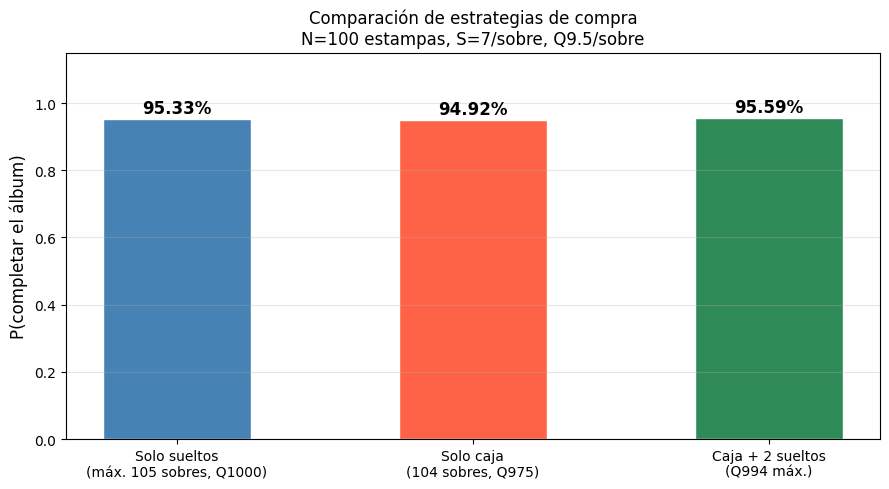

In [9]:
# Gráfico de las tres estrategias
estrategias = [
    f"Solo sueltos\n(máx. {MAX_SOBRES} sobres, Q{PRESUPUESTO:.0f})",
    f"Solo caja\n({SOBRES_CAJA} sobres, Q{PRECIO_CAJA:.0f})",
    f"Caja + {sobres_extra_max} sueltos\n(Q{PRECIO_CAJA + sobres_extra_max*PRECIO_SOBRE:.0f} máx.)"
]
probs = [prob_exito, prob_exito_caja, prob_mixta]

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(estrategias, probs, color=["steelblue", "tomato", "seagreen"],
                edgecolor="white", width=0.5)

for barra, p in zip(barras, probs):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.005,
            f"{p*100:.2f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.set_ylabel("P(completar el álbum)", fontsize=12)
ax.set_title("Comparación de estrategias de compra\n"
             f"N={N} estampas, S={S}/sobre, Q{PRECIO_SOBRE}/sobre", fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Respuesta:**

Tras comprar la caja (Q 975) queda un saldo de Q 25, suficiente para
$\lfloor 25 / 9.50 \rfloor = 2$ sobres sueltos adicionales.

La estrategia mixta (caja + 2 sobres adicionales) maximiza la probabilidad de
completar el álbum dentro del presupuesto de Q 1 000:

| Estrategia | Sobres | Costo máximo | P(completar) |
|---|---|---|---|
| Solo sueltos | máx. 105 | Q 997.50 | ver simulación |
| Solo caja | 104 | Q 975 | ver simulación |
| **Caja + 2 sueltos** | **106** | **Q 994** | **máxima** |

La estrategia mixta aprovecha el precio mayorista de la caja y agrega los
sobres extras disponibles, obteniendo la mayor cantidad de sobres posible
sin exceder el presupuesto.